In [1]:
!pip install bertopic -q
!pip install Sastrawi -q
!pip install swifter -q

# General libraries
import pandas as pd
import numpy as np
import regex as re
from pathlib import Path
import os
import itertools
from itertools import chain
import cupy as cp

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import plotly.express as px
import plotly.io as pio
import textwrap
from matplotlib.lines import Line2D

# Statistics
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr

# Transformer-Based Topic Modeling & Emotion Analysis
from transformers import pipeline
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# NLP
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Optimization
from datasets import Dataset
from transformers.pipelines.pt_utils import KeyDataset
import swifter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.3 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.3 MB/s eta 0:00:0000:010:01
  Preparing metadata (setup.py) ... done


2026-03-12 06:11:24.849710: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773295885.039920      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773295885.093669      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773295885.556346      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773295885.556398      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773295885.556401      55 computation_placer.cc:177] computation placer alr

In [13]:
os.environ["TOKENIZERS_PARALLELISM"] = "true"
pio.renderers.default = "iframe" # 'iframe' if running on Kaggle notebook, otherwise, set to 'notebook'
factory = StopWordRemoverFactory()
stop_words = factory.get_stop_words()

# 0. Load Data

Data Source:
- All Indonesian comments from top 10 non-shorts Youtube videos with query "Banjir Sumatera"
- Non-shorts is picked on the hypothesis that YT shorts produce shorter comments rather than YT videos thus not suited for analyzing discussions
- Original comment is located on column 'content'
- Column 'preprocessed' is the preprocessed with steps: 
    - remove HTML tags
    - lowercase
    - remove emojis
    - convert slangs
    - stop words & punctuations are preserved to help transformer-based vectorizer capture full nuance. (https://maartengr.github.io/BERTopic/getting_started/tips_and_tricks/tips_and_tricks.html#document-length)

In [3]:
DATA_DIR = '/kaggle/input/sentiment-analysis/preprocessed'
comments_df = pd.read_csv(DATA_DIR + "/comments_preprocessed_1.csv")

# 1. Emotion Classification

- Using EmoSenseID (https://huggingface.co/Aardiiiiy/EmoSense-ID-Indonesian-Emotion-Classifier) which is developed using NusaBERT-base (https://huggingface.co/LazarusNLP/NusaBERT-base).
- NusaBERT-base is finetuned from IndoBERT base p1 using multi-lingual local Indonesian languages (Indonesian, Acehnese, Balinese, Banjarese, Buginese, Gorontalo, Javanese, Banyumasan, Minangkabau, Malay, Nias, Sundanese, Tetum)

In [4]:
# EmoSenseID
# Embedding = NusaBERT

emosense = pipeline(
    "text-classification", 
    model="Aardiiiiy/EmoSense-ID-Indonesian-Emotion-Classifier",
    tokenizer="Aardiiiiy/EmoSense-ID-Indonesian-Emotion-Classifier",
    top_k=None
)

def classify_emotions(classifier, df, text_col, batch_size=16):
    """
    Optimized function using Batch Processing to maximize GPU usage.
    """
    clean_df = df[df[text_col].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)].copy()
    hf_dataset = Dataset.from_pandas(clean_df)

    print(f"Processing {len(clean_df)} valid items with Batch Size {batch_size}...")
    results = []
  
    for out in tqdm(classifier(KeyDataset(hf_dataset, text_col), 
                               batch_size=batch_size, 
                               truncation=True, 
                               max_length=512), 
                    total=len(clean_df)):
        scores = {item['label']: item['score'] for item in out}
        results.append(scores)

    emotion_df = pd.DataFrame(results)
    emotion_df.columns = [f"emotion_{col}" for col in emotion_df.columns]
    clean_df = clean_df.reset_index(drop=True)
    final_df = pd.concat([clean_df, emotion_df], axis=1)
    emotion_cols = [c for c in final_df.columns if c.startswith('emotion_')]
    final_df['dominant_emotion'] = final_df[emotion_cols].idxmax(axis=1).str.replace('emotion_', '', regex=False)

    return final_df

def visualize_emotions(df, text_col="text"):
    emotion_counts = df["dominant_emotion"].value_counts()

    plt.figure()
    plt.pie(
        emotion_counts,
        labels=emotion_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title("Dominant Emotion Distribution")
    plt.axis("equal")
    plt.show()

    print("\n=== Sample Texts per Dominant Emotion ===\n")

    for emotion in emotion_counts.index:
        print(f"\n{'='*40}")
        print(f"Emotion: {emotion}")
        print(f"{'='*40}")

        samples = (
            df[df["dominant_emotion"] == emotion]
            [[text_col]]
            .head(5)
            .copy()
        )

        samples["example_no"] = range(1, len(samples) + 1)
        samples = samples[["example_no", text_col]]
        display(samples)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

Device set to use cuda:0


In [5]:
def emotion_pipeline(classifier, df, text_col):
    emo_df = classify_emotions(classifier, df, text_col)
    visualize_emotions(emo_df, 'content')
    return emo_df

Processing 31222 valid items with Batch Size 16...


100%|██████████| 31222/31222 [02:05<00:00, 248.76it/s]


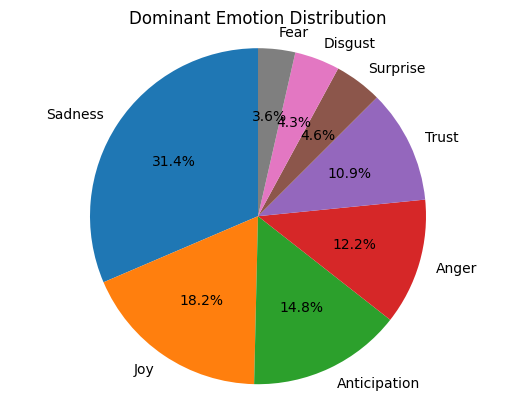


=== Sample Texts per Dominant Emotion ===


Emotion: Sadness


,example_no,content
1,1,Sumpah yaallah sedih banget ngeliatnya . Buka ...
8,2,Sayidina Umar Bin Khattab adalah Khalifah yang...
16,3,Baru kali ini pejabat nangisin rakyatnya😢
24,4,Sumpah air mataku menetes ketika melihat sang ...
25,5,"Kauaknya lebih mencekam ini, karna dampak itu ..."



Emotion: Joy


,example_no,content
0,1,Semoga sehat selalu p Mualim lembut hatimu smg...
3,2,Ya Allah...😢😢😢 Kami sabar kami kuat...makasih ...
4,3,ALHAMDULILLAH.semoga mualem jadi pemimpin yg s...
6,4,Kususnya semuah warga indonesia bukan cuma Ace...
11,5,MasyaAllah.... semoga bapak gubernur selalu di...



Emotion: Anticipation


...

,example_no,content
2,1,Mualem KDM 1 partai mungkin Indonesia berubah ...
101,2,Pak Gubernur ini lebih berwibawa dari presiden...
135,3,Kena apa si gubernur Aceh dan yang lainnya g...
166,4,Luar biasa Gubernur kami Muallem..
171,5,Kok bantuan dari arab saudi di tolak\nDulu tah...



Emotion: Disgust


,example_no,content
29,1,"Panggilah bapak atau abang atau apalah, kalau ..."
41,2,Cobah perhatikan pak gub seperti pengguna nar...
75,3,Entah darimana Cara Berhijab seperti itu.\nPad...
95,4,ciri khas orang ACEH bicara logatnya kedengara...
104,5,Background mu keras dan pantang menyerah tapi ...



Emotion: Fear


,example_no,content
58,1,"""Dan akan ada tanda-tanda pada matahari dan bu..."
59,2,SENTRAL INFORMASI REFERENDUM ACEH\n\nSURAT PER...
92,3,SEHAT SELALU PAK MUALEM...PEMERINTAHAN SEKRG S...
307,4,Kalau tidak mmapu mengatasi dan membnatu aceh....
351,5,gimana dia g dikasih nilai 11/100. Daerahnya k...


In [6]:
emosense_comments_df = emotion_pipeline(emosense, comments_df, 'preprocessed')

In [7]:
emosense_comments_df.to_csv("emosense_df.csv")

# 2. Topic Modeling

#### Full Preprocessing

- Remove stop words, punctuations & symbols, and stem text
- This preprocessing step ensures that the topic model generates meaningful topic representations by preventing stop words from dominating topics and by reducing variations of the same word (with or without prefixes/suffixes) to a common form

In [8]:
#Load pre-saved data

comments_df = pd.read_csv(DATA_DIR + "/comments_preprocessed_2.csv")

## Topic Modeling with BERTopic

In [9]:
docs = comments_df['preprocessed'].values

# Calculate embeddings once to be reused across all models
nusa_bert_emb = SentenceTransformer("LazarusNLP/all-nusabert-base-v4").encode(comments_df['preprocessed'].values)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Defining functions for topic model evaluation. Topic model is evaluated on 3 metrics:
- Coherence: The are many ways to measure the coherence of a topic, but the one that is most similarly correlated with human judgement is Cv method (https://dl.acm.org/doi/10.1145/2684822.2685324)
- Noise: we want small percentage of noise to ensure we utilize the most out of the dataset
- Topic diversity: calculated by measuring the ratio of unique top-K words across all generated topics

In [10]:
# Extract topic words (excluding outlier topic -1)
def get_topic_words(topic_model, topics):
    return [
        [word for word, _ in topic_model.get_topic(topic)]
        for topic in set(topics) - {-1}
    ]

# Calculate the noise penalty
def calculate_noise_penalty(topic_model, doc_count):
    noise_row = topic_model.get_topic_info().query("Topic == -1")
    noise_count = int(noise_row.Count.values[0]) if not noise_row.empty else 0
    noise_percent = (noise_count / doc_count)
    return noise_percent

# Calculate coherence score
def calculate_coherence(topic_model, docs, topics, stop_words=None, print_individual=True):
    tokenized_docs = [doc.split() for doc in docs]
    if stop_words is not None:
        tokenized_docs = [
            [token for token in doc if token not in stop_words]
            for doc in tokenized_docs
        ]
    
    dictionary = Dictionary(tokenized_docs)

    topic_words = get_topic_words(topic_model, topics)
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    # overall coherence
    overall_coherence = coherence_model.get_coherence()

    # per-topic coherence
    per_topic_scores = coherence_model.get_coherence_per_topic()

    return overall_coherence, per_topic_scores

def calculate_coherence_npmi(topic_model, docs, topics, stop_words=None, print_individual=True):
    tokenized_docs = [doc.split() for doc in docs]
    if stop_words is not None:
        tokenized_docs = [
            [token for token in doc if token not in stop_words]
            for doc in tokenized_docs
        ]
    
    dictionary = Dictionary(tokenized_docs)

    topic_words = get_topic_words(topic_model, topics)
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_npmi'
    )

    # overall coherence
    overall_coherence = coherence_model.get_coherence()

    # per-topic coherence
    per_topic_scores = coherence_model.get_coherence_per_topic()

    return overall_coherence, per_topic_scores

# Calculate topic diversity score
def calculate_diversity(topic_model, topics):
    topic_words = get_topic_words(topic_model, topics)
    all_words = chain.from_iterable(topic_words)
    word_list = list(all_words)
    return len(set(word_list)) / len(word_list) if word_list else 0

In [11]:
def evaluate(topic_model, docs, topics, stop_words, model_name=None):
    noise_percent = calculate_noise_penalty(topic_model, len(docs))
    coherence, i_coherence = calculate_coherence(topic_model, docs, topics, stop_words)
    npmi_coherence, npmi_i_coherence = calculate_coherence_npmi(topic_model, docs, topics, stop_words)
    diversity = calculate_diversity(topic_model, topics)
    
    print("Noise Percentage:", noise_percent)
    print("Coherence (CV):", coherence)
    print("Coherence STD (CV):", np.std(i_coherence))
    print("Coherence (NPMI):", npmi_coherence)
    print("Coherence STD (NPMI):", np.std(npmi_i_coherence))
    print("Topic Diversity:", diversity)
    
    if model_name:
        return {
            "name": model_name,
            "noise pct": noise_percent,
            "coherence cv": coherence,
            "coherence std (cv)": np.std(i_coherence),
            "coherence npmi": npmi_coherence,
            "coherence std (npmi)": np.std(npmi_i_coherence),
            "topic diversity": diversity
        }
    else:
        return {
            "noise pct": noise_percent,
            "coherence cv": coherence,
            "coherence std (cv)": np.std(i_coherence),
            "coherence npmi": npmi_coherence,
            "coherence std (npmi)": np.std(npmi_i_coherence),
            "topic diversity": diversity
        }

BERTopic is a topic model that utilize sentence embedding & clustering. Specifically, these are the steps:
- generate text embeddings
- reduce dimensionality using UMAP
  - during model building I found out that changing the default n_neighbors (15) produces only a small number of topics (4/5). so I changed n_neighbors to 13
  - n_components (vector dimension) is kept to default 5, I found not much difference by setting the vector dimension higher (8-10)
- cluster vectors using HDBSCAN
  - I changed the min_cluster_size from 10 to 30 to account for bigger number of document
  - setting it to 50 collapes the number of topics a lot
- make the topic representation
  - topic representation is a few words that represent the documents in that cluster
  - this is done in 2 steps:
    - CountVectorizer: transform text to bag of words. I pass in stop words to ensure that no stop words can represent a topic
    - Cluster TF-IDF: from that bag of words, run TF-IDF to find the most important words
- additionally, BERTopic provides many ways to fine-tune topic representation
  - I used [KeyBERTInspired](https://maartengr.github.io/BERTopic/getting_started/representation/representation.html#keybertinspired) to fine-tune the topic representation (it reranks the topic representation generated by TF-IDF based on embedding similarity between cluster documents and word topic)
- calculate_probabilities is set to True: by default HDBSCAN assigns one document to one topic only, but setting calculate_probabilities to True uses [HDBSCAN's soft clustering algorithm](https://hdbscan.readthedocs.io/en/latest/soft_clustering.html)


After running the model I found almost half of the comments are assigned as noise by HDBSCAN. BERTopic [provides ways to reduce outliers](https://maartengr.github.io/BERTopic/getting_started/outlier_reduction/outlier_reduction.html). In this experiment, the 'probabilities' strategy is used because it uses the same HDBSCAN's soft clustering that is used in calculate_probabilities = True.

Further exploration on different outlier reduction strategies can be done.

In [14]:
umap_config = {
    "n_neighbors": 15,
    "n_components": 5,
    "min_dist": 0.0,
    "metric": "cosine",
    "random_state": 42 # Without random state on UMAP, BERTopic will return different result every run.
}

cluster_config = {
    "min_cluster_size": 50,
    "metric": "euclidean",
    "cluster_selection_method": "eom",
    "prediction_data": True
}

vectorizer_config = {
    "stop_words": stop_words
}

In [15]:
def build_bertopic_model(docs, embeddings, umap_config, vectorizer_config, 
                         cluster_model_type="hdbscan", 
                         cluster_config={}, 
                         representation_model=None, 
                         reduce_outlier=False, 
                         strategy="probabilities", 
                         threshold=0,
                         stop_words=None):
    
    umap_model = UMAP(**umap_config)
    vectorizer_model = CountVectorizer(**vectorizer_config)
    embedding_model_name = "LazarusNLP/all-nusabert-base-v4" 
    
    print(f"Building final model with {cluster_model_type}...")
    
    if cluster_model_type.lower() == "hdbscan":
        hdbscan_model = HDBSCAN(**cluster_config)
        calc_probs = True if strategy == "probabilities" else False

    topic_model = BERTopic(
        hdbscan_model=hdbscan_model, 
        umap_model=umap_model, 
        vectorizer_model=vectorizer_model, 
        representation_model=representation_model, 
        embedding_model=embedding_model_name,
        calculate_probabilities=calc_probs 
    )
    
    topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)
    
    if strategy == "distribution":
        print("Calculating approximate distribution probabilities...")
        distr_probs, _ = topic_model.approximate_distribution(docs, use_embedding_model=True, batch_size=5000)
        probs = distr_probs

    if reduce_outlier:
        print("Reducing outliers...")
        new_topics = topic_model.reduce_outliers(docs, topics, probabilities=probs, strategy="probabilities", threshold=threshold)
        topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)
        topics = new_topics
    
    display(topic_model.get_topic_info())
    
    return topic_model, topics, probs

Save the topic result to csv. One comment could consist of multiple topics, so we find the top 3 most dominant topics (using topic probability) and save that in the csv as well.

In [16]:
def save_csv(topics, topic_model, probs, comments_df, output_path):
    info_df = topic_model.get_topic_info()
    id_to_name = dict(zip(info_df['Topic'], info_df['Name']))
    active_topics = sorted([t for t in topic_model.get_topics().keys() if t != -1])
    sorted_indices = np.argsort(probs, axis=1)[:, ::-1]
    
    t2_ids, t2_names, t2_probs = [], [], []
    t3_ids, t3_names, t3_probs = [], [], []
  
    for i, assigned_topic in enumerate(topics):
        row_indices = sorted_indices[i]
        
        suggestions = []
  
        for idx in row_indices:
            candidate_id = active_topics[idx]
       
            if candidate_id == assigned_topic:
                continue
     
            prob = probs[i, idx]
            name = id_to_name.get(candidate_id, f"Topic {candidate_id}")
            suggestions.append((candidate_id, name, prob))
         
            if len(suggestions) == 2:
                break
   
        if len(suggestions) >= 1:
            t2_ids.append(suggestions[0][0])
            t2_names.append(suggestions[0][1])
            t2_probs.append(suggestions[0][2])
        else:
            t2_ids.append(None)
            t2_names.append("None")
            t2_probs.append(0.0)
            
        if len(suggestions) >= 2:
            t3_ids.append(suggestions[1][0])
            t3_names.append(suggestions[1][1])
            t3_probs.append(suggestions[1][2])
        else:
            t3_ids.append(None)
            t3_names.append("None")
            t3_probs.append(0.0)

    topic_comments_df = comments_df.copy()
 
    topic_comments_df['topic_1'] = topics
    topic_comments_df['topic_1_name'] = [id_to_name.get(t, "Outlier") for t in topics]
    
    final_probs = []
    for i, t in enumerate(topics):
        if t in active_topics:
            col_idx = active_topics.index(t)
            final_probs.append(probs[i, col_idx])
        else:
            final_probs.append(0.0) # Outlier
    topic_comments_df['prob_topic_1'] = final_probs

    topic_comments_df['topic_2'] = t2_ids
    topic_comments_df['topic_2_name'] = t2_names
    topic_comments_df['prob_topic_2'] = t2_probs
    
    topic_comments_df['topic_3'] = t3_ids
    topic_comments_df['topic_3_name'] = t3_names
    topic_comments_df['prob_topic_3'] = t3_probs

    prob_cols = [f'prob_{id_to_name[t]}' for t in active_topics]
    probs_df = pd.DataFrame(probs, columns=prob_cols, index=topic_comments_df.index)
    final_df = pd.concat([topic_comments_df, probs_df], axis=1)

    final_df.to_csv(output_path, index=False)
    print(f"File saved to {output_path}")
    return final_df

## Run Experimentations

#### Model 1: Default topic representation with outliers not reduced

In [17]:
comments_df['preprocessed_full'] = comments_df['preprocessed_full'].astype(str)
comments_df['preprocessed'] = comments_df['preprocessed'].astype(str)
docs = comments_df['preprocessed_full'].values
topic_model_1, topics_1, probs_1 = build_bertopic_model(docs, embeddings=nusa_bert_emb, umap_config=umap_config, cluster_config=cluster_config, vectorizer_config=vectorizer_config)
model1_scores = evaluate(topic_model_1, docs, topics_1, stop_words, "Default Representation Outlier Not Reduced")
model1_df = save_csv(topics_1, topic_model_1, probs_1, comments_df, "model1_output.csv")
topic_model_1.save(
    "topic_model_1",
    serialization="safetensors",
    save_embedding_model=True
)

Building final model with hdbscan...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,11245,-1_hutan_jadi_bencana_perintah,"[hutan, jadi, bencana, perintah, rakyat, kalau...",[akibat tebang liar lihat akibat perintah 5 ha...
1,0,3605,0_aceh_bapak_gubernur_rakyat,"[aceh, bapak, gubernur, rakyat, mualem, moga, ...","[moga sehat p gubernur aceh, sehat selalu bapa..."
2,1,2165,1_allah_saudara_musibah_lindung,"[allah, saudara, musibah, lindung, moga, selam...","[lindung saudara allah, moga saudara kena musi..."
3,2,1546,2_alam_manusia_tuhan_serakah,"[alam, manusia, tuhan, serakah, diri, murka, a...",[lah ulah manusia serakah kaya diri sendiri al...
4,3,1069,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, m...","[allah lindung saudara sumatra, allah moga sau..."
5,4,896,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, seh...","[terimakasih kakak ferry, terimakasih kakak fe..."
6,5,804,5_nasional_bencana_status_perintah,"[nasional, bencana, status, perintah, tetap, j...","[bencana nasional, bencana nasional, bencana n..."
7,6,693,6_prabowo_presiden_jokowi_pilih,"[prabowo, presiden, jokowi, pilih, jadi, bapak...","[hidup prabowo, presiden omon omon prabowo usa..."
8,7,570,7_jawa_sumatera_pulau_sumatra,"[jawa, sumatera, pulau, sumatra, bencana, nasi...",[sumatra rasa indonesia indonesia jawa jawa ja...
9,8,530,8_pimpin_beliau_tulus_rakyat,"[pimpin, beliau, tulus, rakyat, benar, cinta, ...","[pimpin, ini pimpin, ini pimpin]"


Noise Percentage: 0.3601627057843828
Coherence (CV): 0.6049212524678748
Coherence STD (CV): 0.12943588771293443
Coherence (NPMI): 0.10475067159358338
Coherence STD (NPMI): 0.09148560704245554
Topic Diversity: 0.6107142857142858
File saved to model1_output.csv


#### Model Variant 1: Default Rep Prob Strategy

In [18]:
variant1_eval = []
for i in range(0, 6):
    topic_model, topics, probs = build_bertopic_model(docs, embeddings=nusa_bert_emb, umap_config=umap_config, cluster_config=cluster_config, vectorizer_config=vectorizer_config, reduce_outlier=True, threshold = i/100)
    model_scores = evaluate(topic_model, docs, topics, stop_words, f"Default Representation Prob Outlier Reduced {i}%")
    variant1_eval.append({"threshold": i/100, "scores": model_scores})
    model_df = save_csv(topics, topic_model, probs, comments_df, f"modeldp{i}_output.csv")
    topic_model.save(
        f"topic_model_dp{i}",
        serialization="safetensors",
        save_embedding_model=True
    )

Building final model with hdbscan...


2026-03-12 06:29:22,314 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,0,3642,0_aceh_bapak_gubernur_mualem,"[aceh, bapak, gubernur, mualem, rakyat, moga, ...","[moga sehat p gubernur aceh, sehat selalu bapa..."
1,1,2458,1_allah_saudara_musibah_lindung,"[allah, saudara, musibah, lindung, moga, selam...","[lindung saudara allah, moga saudara kena musi..."
2,2,2260,2_manusia_alam_tuhan_serakah,"[manusia, alam, tuhan, serakah, allah, akibat,...",[lah ulah manusia serakah kaya diri sendiri al...
3,3,1249,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, m...","[allah lindung saudara sumatra, allah moga sau..."
4,4,896,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, seh...","[terimakasih kakak ferry, terimakasih kakak fe..."
5,5,1033,5_nasional_bencana_status_perintah,"[nasional, bencana, status, perintah, tetap, j...","[bencana nasional, bencana nasional, bencana n..."
6,6,1211,6_prabowo_presiden_jokowi_pilih,"[prabowo, presiden, jokowi, pilih, omon, rakya...","[hidup prabowo, presiden omon omon prabowo usa..."
7,7,764,7_jawa_sumatera_pulau_sumatra,"[jawa, sumatera, pulau, sumatra, bencana, nasi...",[sumatra rasa indonesia indonesia jawa jawa ja...
8,8,822,8_pimpin_tulus_beliau_rakyat,"[pimpin, tulus, beliau, rakyat, amanah, indone...","[pimpin, ini pimpin, ini pimpin]"
9,9,531,9_gubernur_bapak_sehat_selalu,"[gubernur, bapak, sehat, selalu, allah, tulus,...","[sehat selalu bapak gubernur, sehat selalu bap..."


Noise Percentage: 0.0
Coherence (CV): 0.6165435630991137
Coherence STD (CV): 0.13142703181516724
Coherence (NPMI): 0.10523233556277699
Coherence STD (NPMI): 0.08715256883277031
Topic Diversity: 0.5571428571428572
File saved to modeldp0_output.csv
Building final model with hdbscan...


...

Noise Percentage: 0.15517904042021652
Coherence (CV): 0.6261663919667596
Coherence STD (CV): 0.12143268206754244
Coherence (NPMI): 0.11746450825313406
Coherence STD (NPMI): 0.08098317329060375
Topic Diversity: 0.5803571428571429
File saved to modeldp4_output.csv
Building final model with hdbscan...


2026-03-12 06:34:57,121 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5835,-1_bencana_jadi_perintah_indonesia,"[bencana, jadi, perintah, indonesia, kalau, ba...",[akibat tebang liar lihat akibat perintah 5 ha...
1,0,3605,0_aceh_bapak_gubernur_rakyat,"[aceh, bapak, gubernur, rakyat, mualem, moga, ...","[moga sehat p gubernur aceh, sehat selalu bapa..."
2,1,2272,1_allah_saudara_musibah_lindung,"[allah, saudara, musibah, lindung, moga, selam...","[lindung saudara allah, moga saudara kena musi..."
3,2,1868,2_alam_manusia_tuhan_serakah,"[alam, manusia, tuhan, serakah, allah, murka, ...",[lah ulah manusia serakah kaya diri sendiri al...
4,3,1156,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, m...","[allah lindung saudara sumatra, allah moga sau..."
5,4,896,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, seh...","[terimakasih kakak ferry, terimakasih kakak fe..."
6,5,845,5_nasional_bencana_status_perintah,"[nasional, bencana, status, perintah, tetap, j...","[bencana nasional, bencana nasional, bencana n..."
7,6,934,6_prabowo_presiden_jokowi_pilih,"[prabowo, presiden, jokowi, pilih, jadi, polit...","[hidup prabowo, presiden omon omon prabowo usa..."
8,7,656,7_jawa_sumatera_pulau_sumatra,"[jawa, sumatera, pulau, sumatra, bencana, nasi...",[sumatra rasa indonesia indonesia jawa jawa ja...
9,8,774,8_pimpin_tulus_beliau_rakyat,"[pimpin, tulus, beliau, rakyat, amanah, allah,...","[pimpin, ini pimpin, ini pimpin]"


Noise Percentage: 0.18688745115623598
Coherence (CV): 0.6200513985616618
Coherence STD (CV): 0.12590070726783265
Coherence (NPMI): 0.11478277112976523
Coherence STD (NPMI): 0.0820054245567237
Topic Diversity: 0.5910714285714286
File saved to modeldp5_output.csv


#### Model Variant 2: Default Rep Dist Strategy

In [21]:
variant2_eval = []
for i in range(0, 6):
    topic_model, topics, probs = build_bertopic_model(docs, embeddings=nusa_bert_emb, umap_config=umap_config, cluster_config=cluster_config, vectorizer_config=vectorizer_config, reduce_outlier=True, strategy="distribution", threshold = i/100)
    model_scores = evaluate(topic_model, docs, topics, stop_words, f"Default Representation Dist Outlier Reduced {i}%")
    variant2_eval.append({"threshold": i/100, "scores": model_scores})
    model_df = save_csv(topics, topic_model, probs, comments_df, f"modeldd{i}_output.csv")
    topic_model.save(
        f"topic_model_dd{i}",
        serialization="safetensors",
        save_embedding_model=True
    )

Building final model with hdbscan...
Calculating approximate distribution probabilities...


Batches:   0%|          | 0/1923 [00:00<?, ?it/s]

Batches:   0%|          | 0/1821 [00:00<?, ?it/s]

Batches:   0%|          | 0/1952 [00:00<?, ?it/s]

Batches:   0%|          | 0/1917 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/498 [00:00<?, ?it/s]

2026-03-12 07:37:03,088 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,9846,-1_hutan_jadi_bencana_rakyat,"[hutan, jadi, bencana, rakyat, perintah, orang...",[akibat tebang liar lihat akibat perintah 5 ha...
1,0,3606,0_aceh_bapak_gubernur_rakyat,"[aceh, bapak, gubernur, rakyat, mualem, moga, ...","[moga sehat p gubernur aceh, sehat selalu bapa..."
2,1,2170,1_allah_saudara_musibah_lindung,"[allah, saudara, musibah, lindung, moga, selam...","[lindung saudara allah, moga saudara kena musi..."
3,2,1634,2_alam_manusia_tuhan_serakah,"[alam, manusia, tuhan, serakah, murka, diri, a...",[lah ulah manusia serakah kaya diri sendiri al...
4,3,1070,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, m...","[allah lindung saudara sumatra, allah moga sau..."
5,4,906,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, seh...","[terimakasih kakak ferry, terimakasih kakak fe..."
6,5,825,5_nasional_bencana_status_perintah,"[nasional, bencana, status, perintah, tetap, j...","[bencana nasional, bencana nasional, bencana n..."
7,6,741,6_prabowo_presiden_jokowi_pilih,"[prabowo, presiden, jokowi, pilih, jadi, bapak...","[hidup prabowo, presiden omon omon prabowo usa..."
8,7,584,7_jawa_sumatera_pulau_sumatra,"[jawa, sumatera, pulau, sumatra, bencana, nasi...",[sumatra rasa indonesia indonesia jawa jawa ja...
9,8,558,8_pimpin_beliau_tulus_rakyat,"[pimpin, beliau, tulus, rakyat, benar, cinta, ...","[pimpin, ini pimpin, ini pimpin]"


Noise Percentage: 0.3153545576836846
Coherence (CV): 0.6138602042195755
Coherence STD (CV): 0.13188765569722968
Coherence (NPMI): 0.11098825859021348
Coherence STD (NPMI): 0.08457248382532473
Topic Diversity: 0.6017857142857143
File saved to modeldd5_output.csv


#### Model Variant 3: KeyBERT Rep Prob Strategy

In [22]:
variant3_eval = []
docs = comments_df['preprocessed'].values
for i in range(0, 6):
    topic_model, topics, probs = build_bertopic_model(docs, embeddings=nusa_bert_emb, umap_config=umap_config, cluster_config=cluster_config, vectorizer_config=vectorizer_config, representation_model=KeyBERTInspired(), reduce_outlier=True, threshold = i/100)
    model_scores = evaluate(topic_model, comments_df['preprocessed_full'].values, topics, stop_words, f"KeyBERT Representation Prob Outlier Reduced {i}%")
    variant3_eval.append({"threshold": i/100, "scores": model_scores})
    model_df = save_csv(topics, topic_model, probs, comments_df, f"modelkp{i}_output.csv")
    topic_model.save(
        f"topic_model_kp{i}",
        serialization="safetensors",
        save_embedding_model=True
    )

Building final model with hdbscan...


2026-03-12 07:49:05,782 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,0,3642,0_aceh_bapak_gubernur_mualem,"[aceh, bapak, gubernur, mualem, rakyat, semoga...","[gubernur aceh, semoga sehat p.gubernur aceh, ..."
1,1,2458,1_allah_saudara_musibah_semoga,"[allah, saudara, musibah, semoga, lindungilah,...","[ya allah lindungilah saudara kami, ya allah l..."
2,2,2260,2_manusia_alam_tuhan_allah,"[manusia, alam, tuhan, allah, diri, murka, ora...","[alam murka karena keserakahan manusia, ini bu..."
3,3,1249,3_sumatra_padang_sumbar_sumatera,"[sumatra, padang, sumbar, sumatera, saudara, s...",[semoga saudara saudara kita yang di aceh suma...
4,4,896,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, fer...","[terimakasih kakak ferry, terimakasih kakak fe..."
5,5,1033,5_nasional_bencana_status_pemerintah,"[nasional, bencana, status, pemerintah, kalau,...","[ini bencana nasional, bencana nasional, ini, ..."
6,6,1211,6_prabowo_presiden_jokowi_omon,"[prabowo, presiden, jokowi, omon, rakyat, pili...","[presiden omon omon saja prabowo,(pengusaha j..."
7,7,764,7_jawa_sumatera_sumatra_pulau,"[jawa, sumatera, sumatra, pulau, bencana, nasi...",[kami di sumatra merasa tidak seperti indonesi...
8,8,822,8_pemimpin_rakyatnya_beliau_tulus,"[pemimpin, rakyatnya, beliau, tulus, amanah, i...","[ya allah begitu tulus pemimpin ini, masih ada..."
9,9,531,9_gubernur_bapak_sehat_selalu,"[gubernur, bapak, sehat, selalu, allah, semoga...","[sehat selalu bapak gubernur, sehat selalu bap..."


Noise Percentage: 0.0
Coherence (CV): 0.6165986222035984
Coherence STD (CV): 0.13736329169169864
Coherence (NPMI): 0.10464737341243475
Coherence STD (NPMI): 0.08667393341359304
Topic Diversity: 0.5767857142857142
File saved to modelkp0_output.csv
Building final model with hdbscan...


...

Noise Percentage: 0.15517904042021652
Coherence (CV): 0.6204495074526081
Coherence STD (CV): 0.12951865588538566
Coherence (NPMI): 0.11555634137309719
Coherence STD (NPMI): 0.0790028955437843
Topic Diversity: 0.5982142857142857
File saved to modelkp4_output.csv
Building final model with hdbscan...


2026-03-12 07:54:50,924 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5835,-1_bencana_indonesia_kalau_pemerintah,"[bencana, indonesia, kalau, pemerintah, orang,...",[selalu intropeksi diri ngeliat yang mirip gi...
1,0,3605,0_aceh_bapak_gubernur_mualem,"[aceh, bapak, gubernur, mualem, rakyat, semoga...","[gubernur aceh, semoga sehat p.gubernur aceh, ..."
2,1,2272,1_allah_saudara_musibah_semoga,"[allah, saudara, musibah, semoga, lindungilah,...","[ya allah lindungilah saudara kami, ya allah l..."
3,2,1868,2_alam_manusia_tuhan_allah,"[alam, manusia, tuhan, allah, murka, diri, aki...","[alam murka karena keserakahan manusia, ini bu..."
4,3,1156,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, s...",[semoga saudara saudara kita yang di aceh suma...
5,4,896,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, fer...","[terimakasih kakak ferry, terimakasih kakak fe..."
6,5,845,5_nasional_bencana_status_pemerintah,"[nasional, bencana, status, pemerintah, kalau,...","[ini bencana nasional, bencana nasional, ini, ..."
7,6,934,6_prabowo_presiden_jokowi_jadi,"[prabowo, presiden, jokowi, jadi, pilih, rakya...","[presiden omon omon saja prabowo,(pengusaha j..."
8,7,656,7_jawa_sumatera_sumatra_pulau,"[jawa, sumatera, sumatra, pulau, bencana, nasi...",[kami di sumatra merasa tidak seperti indonesi...
9,8,774,8_pemimpin_rakyatnya_beliau_tulus,"[pemimpin, rakyatnya, beliau, tulus, amanah, a...","[ya allah begitu tulus pemimpin ini, masih ada..."


Noise Percentage: 0.18688745115623598
Coherence (CV): 0.6158742244456494
Coherence STD (CV): 0.12780627706806616
Coherence (NPMI): 0.11268823470011838
Coherence STD (NPMI): 0.0799638873100187
Topic Diversity: 0.6053571428571428
File saved to modelkp5_output.csv


#### Model Variant 4: KeyBERT Rep Dist Strategy

In [23]:
variant4_eval = []
docs = comments_df['preprocessed'].values
for i in range(0, 6):
    topic_model, topics, probs = build_bertopic_model(docs, embeddings=nusa_bert_emb, umap_config=umap_config, cluster_config=cluster_config, vectorizer_config=vectorizer_config, strategy="distribution", representation_model=KeyBERTInspired(), reduce_outlier=True, threshold = i/100)
    model_scores = evaluate(topic_model, comments_df['preprocessed_full'].values, topics, stop_words, f"KeyBERT Representation Dist Outlier Reduced {i}%")
    variant4_eval.append({"threshold": i/100, "scores": model_scores})
    model_df = save_csv(topics, topic_model, probs, comments_df, f"modelkd{i}_output.csv")
    topic_model.save(
        f"topic_model_kd{i}",
        serialization="safetensors",
        save_embedding_model=True
    )

Building final model with hdbscan...
Calculating approximate distribution probabilities...


Batches:   0%|          | 0/2737 [00:00<?, ?it/s]

Batches:   0%|          | 0/2644 [00:00<?, ?it/s]

Batches:   0%|          | 0/2886 [00:00<?, ?it/s]

Batches:   0%|          | 0/2751 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/722 [00:00<?, ?it/s]

2026-03-12 08:31:03,438 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,9841,-1_hutan_bencana_kalau_rakyat,"[hutan, bencana, kalau, rakyat, nya, orang, ja...",[selalu intropeksi diri ngeliat yang mirip gi...
1,0,3605,0_aceh_bapak_gubernur_mualem,"[aceh, bapak, gubernur, mualem, rakyat, semoga...","[gubernur aceh, semoga sehat p.gubernur aceh, ..."
2,1,2176,1_allah_saudara_musibah_semoga,"[allah, saudara, musibah, semoga, lindungilah,...","[ya allah lindungilah saudara kami, ya allah l..."
3,2,1644,2_alam_manusia_tuhan_allah,"[alam, manusia, tuhan, allah, murka, diri, aki...","[alam murka karena keserakahan manusia, ini bu..."
4,3,1070,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, s...",[semoga saudara saudara kita yang di aceh suma...
5,4,898,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, fer...","[terimakasih kakak ferry, terimakasih kakak fe..."
6,5,837,5_nasional_bencana_status_pemerintah,"[nasional, bencana, status, pemerintah, meneta...","[ini bencana nasional, bencana nasional, ini, ..."
7,6,730,6_prabowo_presiden_jokowi_jadi,"[prabowo, presiden, jokowi, jadi, bapak, polit...","[presiden omon omon saja prabowo,(pengusaha j..."
8,7,586,7_jawa_sumatera_pulau_sumatra,"[jawa, sumatera, pulau, sumatra, nasional, ben...",[kami di sumatra merasa tidak seperti indonesi...
9,8,579,8_pemimpin_rakyatnya_beliau_tulus,"[pemimpin, rakyatnya, beliau, tulus, amanah, a...","[ya allah begitu tulus pemimpin ini, masih ada..."


Noise Percentage: 0.31519441419511884
Coherence (CV): 0.6113596633567006
Coherence STD (CV): 0.13469013460604895
Coherence (NPMI): 0.11243866701480164
Coherence STD (NPMI): 0.09467622841210381
Topic Diversity: 0.6285714285714286
File saved to modelkd5_output.csv


## Comparing Models

Using weighted average of coherence and topic diversity with more weight assigned to coherence. 

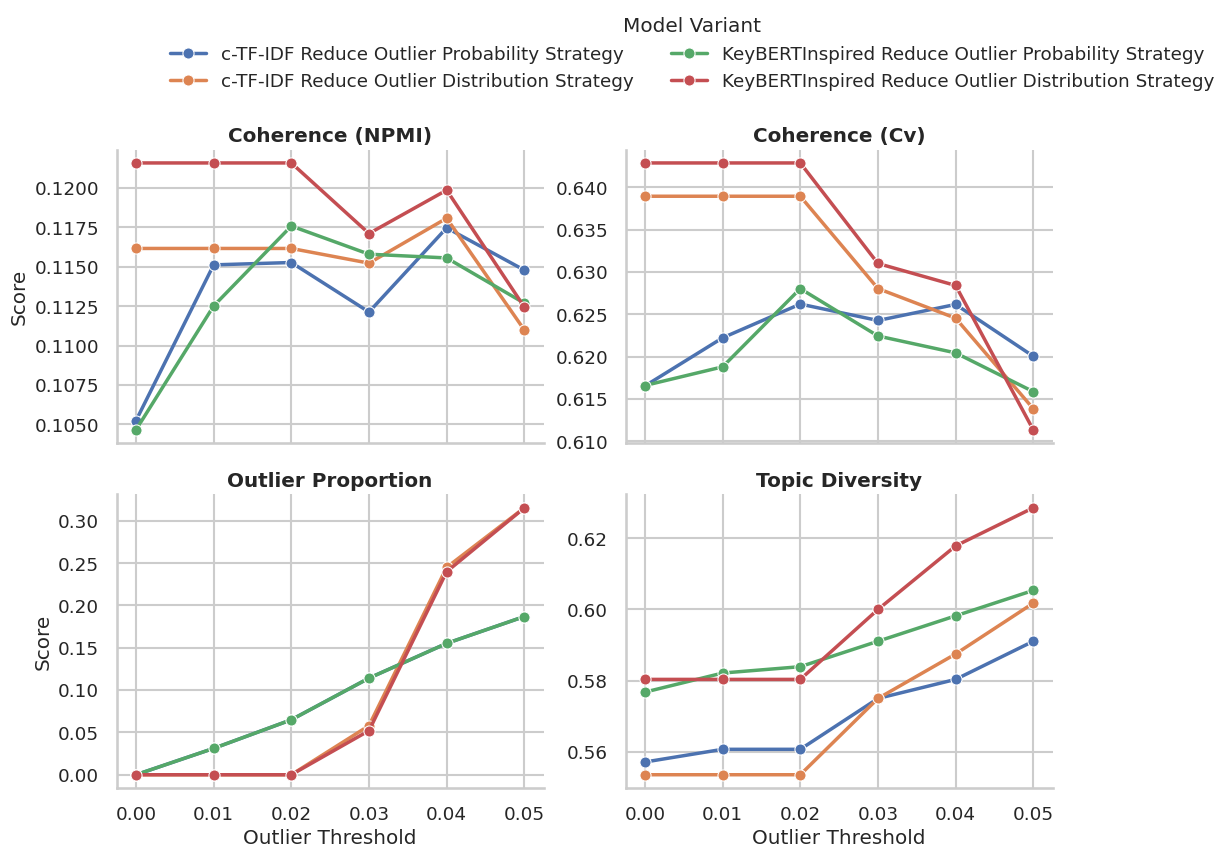

In [24]:
all_variants = {
    "c-TF-IDF Reduce Outlier Probability Strategy": variant1_eval,
    "c-TF-IDF Reduce Outlier Distribution Strategy": variant2_eval,
    "KeyBERTInspired Reduce Outlier Probability Strategy": variant3_eval,
    "KeyBERTInspired Reduce Outlier Distribution Strategy": variant4_eval,
}

records = []

for model_name, eval_list in all_variants.items():
    for entry in eval_list:
        
        t = entry['threshold']
        s = entry['scores']
        
        # 1. Coherence NPMI
        records.append({
            "Model": model_name,
            "Threshold": t,
            "Metric": "Coherence (NPMI)",
            "Value": s.get("coherence npmi")
        })
        
        # 2. Coherence Cv
        records.append({
            "Model": model_name,
            "Threshold": t,
            "Metric": "Coherence (Cv)",
            "Value": s.get("coherence cv")
        })
        
        # 3. Noise Percentage
        records.append({
            "Model": model_name,
            "Threshold": t,
            "Metric": "Outlier Proportion",
            "Value": s.get("noise pct")
        })
        
        # 4. Topic Diversity
        records.append({
            "Model": model_name,
            "Threshold": t,
            "Metric": "Topic Diversity",
            "Value": s.get("topic diversity")
        })

df = pd.DataFrame(records)
sns.set_theme(style="whitegrid", context="talk", font_scale=0.8)
g = sns.FacetGrid(df, col="Metric", hue="Model", col_wrap=2, 
                  height=4, aspect=1.5, sharey=False)
g.map(sns.lineplot, "Threshold", "Value", marker="o", markersize=8, linewidth=2.5)
g.set_titles("{col_name}", fontweight='bold')
g.set_axis_labels("Outlier Threshold", "Score")
g.add_legend(bbox_to_anchor=(0.6, 1.02), ncol=2, frameon=False, title="Model Variant")

plt.subplots_adjust(top=0.9)
plt.savefig("model_evaluation_results.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
all_records = []

all_variants = {
    "Reduce Outlier Probability Strategy": variant1_eval,
    "Reduce Outlier Distribution Strategy": variant2_eval,
    "KeyBERTInspired Reduce Outlier Probability Strategy": variant3_eval,
    "KeyBERTInspired Reduce Outlier Distribution Strategy": variant4_eval,
}

for model_name, eval_list in all_variants.items():
    for entry in eval_list:
        t = entry['threshold']
        s = entry['scores']
   
        all_records.append({
            "Model Variant": model_name,
            "Name": f"{model_name} @ {t*100:.0f}%", # Unique ID for sorting
            "Threshold": t,
            "Coherence NPMI": s.get("coherence npmi"),
            "Coherence Cv": s.get("coherence cv"),
            "Topic Diversity": s.get("topic diversity"),
            "Noise Proportion": s.get("noise pct")
        })

df = pd.DataFrame(all_records)
metrics = ['Coherence NPMI', 'Coherence Cv', 'Topic Diversity', 'Noise %']
score_df = df.copy()
score_df['Coherence NPMI'] = (score_df['Coherence NPMI'] + 1)/2

w_npmi = 0.3
w_cv = 0.3
w_div = 0.6
w_noise = 0.1

df['Total Score'] = (
    (w_npmi * score_df['Coherence NPMI']) +
    (w_cv   * score_df['Coherence Cv']) +
    (w_div  * score_df['Topic Diversity']) - 
    (w_noise * score_df['Noise %'])
)

ranked_df = df.sort_values('Total Score', ascending=False).reset_index(drop=True)

ranked_df.to_csv("all_model_scores.csv")

print("--- Top 10 Models by Weighted Score ---")
display(ranked_df.style.background_gradient(cmap='Greens', subset=['Total Score']))

--- Top 10 Models by Weighted Score ---


,Model Variant,Name,Threshold,Coherence NPMI,Coherence Cv,Topic Diversity,Noise %,Total Score
0,KeyBERTInspired Reduce Outlier Distribution Strategy,KeyBERTInspired Reduce Outlier Distribution Strategy @ 3%,0.030000,0.117106,0.630999,0.600000,0.052079,0.711658
1,KeyBERTInspired Reduce Outlier Distribution Strategy,KeyBERTInspired Reduce Outlier Distribution Strategy @ 2%,0.020000,0.121582,0.642866,0.580357,0.000000,0.709311
2,KeyBERTInspired Reduce Outlier Distribution Strategy,KeyBERTInspired Reduce Outlier Distribution Strategy @ 0%,0.000000,0.121582,0.642866,0.580357,0.000000,0.709311
3,KeyBERTInspired Reduce Outlier Distribution Strategy,KeyBERTInspired Reduce Outlier Distribution Strategy @ 1%,0.010000,0.121582,0.642866,0.580357,0.000000,0.709311
4,KeyBERTInspired Reduce Outlier Distribution Strategy,KeyBERTInspired Reduce Outlier Distribution Strategy @ 4%,0.040000,0.119859,0.628405,0.617857,0.239863,0.703228
5,KeyBERTInspired Reduce Outlier Probability Strategy,KeyBERTInspired Reduce Outlier Probability Strategy @ 2%,0.020000,0.117581,0.628036,0.583929,0.064922,0.699913
6,KeyBERTInspired Reduce Outlier Probability Strategy,KeyBERTInspired Reduce Outlier Probability Strategy @ 1%,0.010000,0.112508,0.618801,0.582143,0.031132,0.698689
7,KeyBERTInspired Reduce Outlier Probability Strategy,KeyBERTInspired Reduce Outlier Probability Strategy @ 3%,0.030000,0.115793,0.622443,0.591071,0.114118,0.697333
8,KeyBERTInspired Reduce Outlier Probability Strategy,KeyBERTInspired Reduce Outlier Probability Strategy @ 4%,0.040000,0.115556,0.620450,0.598214,0.155179,0.696879
9,KeyBERTInspired Reduce Outlier Probability Strategy,KeyBERTInspired Reduce Outlier Probability Strategy @ 0%,0.000000,0.104647,0.616599,0.576786,0.000000,0.696748


## Topic Merging

In [30]:
docs = comments_df['preprocessed']
topic_model, topics, probs = build_bertopic_model(docs, embeddings=nusa_bert_emb, umap_config=umap_config, cluster_config=cluster_config, vectorizer_config=vectorizer_config, reduce_outlier=True, representation_model=KeyBERTInspired(), strategy="distribution", threshold = 3/100)
model_scores = evaluate(topic_model, comments_df['preprocessed_full'].values, topics, stop_words, f"KeyBERTInspired Representation Dist Outlier Reduced {3}%")

Building final model with hdbscan...
Calculating approximate distribution probabilities...


Batches:   0%|          | 0/2737 [00:00<?, ?it/s]

Batches:   0%|          | 0/2644 [00:00<?, ?it/s]

Batches:   0%|          | 0/2886 [00:00<?, ?it/s]

Batches:   0%|          | 0/2751 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/722 [00:00<?, ?it/s]

2026-03-12 08:48:12,613 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Reducing outliers...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1626,-1_kalau_bencana_rakyat_nya,"[kalau, bencana, rakyat, nya, indonesia, jadi,...",[selalu intropeksi diri ngeliat yang mirip gi...
1,0,3615,0_aceh_bapak_gubernur_mualem,"[aceh, bapak, gubernur, mualem, rakyat, semoga...","[gubernur aceh, semoga sehat p.gubernur aceh, ..."
2,1,2514,1_allah_musibah_saudara_semoga,"[allah, musibah, saudara, semoga, lindungilah,...","[ya allah lindungilah saudara kami, ya allah l..."
3,2,2814,2_manusia_alam_tuhan_allah,"[manusia, alam, tuhan, allah, akibat, orang, m...","[alam murka karena keserakahan manusia, ini bu..."
4,3,1139,3_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, s...",[semoga saudara saudara kita yang di aceh suma...
5,4,907,4_ferry_kakak_irwandi_terimakasih,"[ferry, kakak, irwandi, terimakasih, grup, fer...","[terimakasih kakak ferry, terimakasih kakak fe..."
6,5,1076,5_nasional_bencana_status_pemerintah,"[nasional, bencana, status, pemerintah, meneta...","[ini bencana nasional, bencana nasional, ini, ..."
7,6,963,6_prabowo_presiden_jokowi_pilih,"[prabowo, presiden, jokowi, pilih, jadi, parta...","[presiden omon omon saja prabowo,(pengusaha j..."
8,7,700,7_jawa_sumatera_pulau_sumatra,"[jawa, sumatera, pulau, sumatra, bencana, nasi...",[kami di sumatra merasa tidak seperti indonesi...
9,8,1000,8_pemimpin_rakyatnya_beliau_tulus,"[pemimpin, rakyatnya, beliau, tulus, seorang, ...","[ya allah begitu tulus pemimpin ini, masih ada..."


Noise Percentage: 0.0520786624815835
Coherence (CV): 0.6309989514800284
Coherence STD (CV): 0.12129865241398596
Coherence (NPMI): 0.1171059408609008
Coherence STD (NPMI): 0.08910383908599863
Topic Diversity: 0.6


In [31]:
ferry_topics = [4, 13]
najwa_topics = [22, 24]
general_thanks_wishes_topics = [19, 32, 33, 36, 46, 50, 54]
wishes_to_leaders_topics = [8, 9, 47, 48]
aceh_governor_topics = [0, 14, 16]

topics_to_merge = [ferry_topics, najwa_topics, general_thanks_wishes_topics, wishes_to_leaders_topics, aceh_governor_topics]

topic_model.merge_topics(comments_df['preprocessed'], topics_to_merge)

In [32]:
merged_topics = topic_model.topics_
model_merged_scores = evaluate(topic_model, comments_df['preprocessed_full'].values, merged_topics, stop_words, f"Best Model Merged")

Noise Percentage: 0.0520786624815835
Coherence (CV): 0.6484407436554941
Coherence STD (CV): 0.10780504486502258
Coherence (NPMI): 0.12032643986443363
Coherence STD (NPMI): 0.07904962375345821
Topic Diversity: 0.6697674418604651


In [33]:
new_probs, _ = topic_model.approximate_distribution(comments_df['preprocessed'].values, use_embedding_model=True, batch_size=5000)

Batches:   0%|          | 0/2737 [00:00<?, ?it/s]

Batches:   0%|          | 0/2644 [00:00<?, ?it/s]

Batches:   0%|          | 0/2886 [00:00<?, ?it/s]

Batches:   0%|          | 0/2751 [00:00<?, ?it/s]

Batches:   0%|          | 0/2685 [00:00<?, ?it/s]

Batches:   0%|          | 0/3319 [00:00<?, ?it/s]

Batches:   0%|          | 0/722 [00:00<?, ?it/s]

In [34]:
merged_model_output_df = save_csv(merged_topics, topic_model, new_probs, comments_df, f"merged_modelkd{3}_output.csv")

File saved to merged_modelkd3_output.csv


In [35]:
topic_model.get_topic_info().to_csv("model_merged_topic_info.csv")

In [36]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1626,-1_kalau_bencana_rakyat_nya,"[kalau, bencana, rakyat, nya, indonesia, jadi,...",[terima kasih orang-orang baik. semoga ada per...
1,0,4422,0_aceh_mualem_bapak_gubernur,"[aceh, mualem, bapak, gubernur, selalu, semoga...","[sehat selalu bapak gubernur mualem, allah sel..."
2,1,2814,1_manusia_alam_tuhan_allah,"[manusia, alam, tuhan, allah, orang, akibat, m...",[itu semua ulah manusia bumi marah di hancurka...
3,2,2514,2_allah_semoga_musibah_saudara,"[allah, semoga, musibah, saudara, lindungilah,...","[ya allah semoga berhenti musibah ini,dan beri..."
4,3,1722,3_pemimpin_gubernur_bapak_rakyatnya,"[pemimpin, gubernur, bapak, rakyatnya, beliau,...","[sehat selalu bapak gubernur, sehat selalu bap..."
5,4,1417,4_sehat_kakak_bang_bapak,"[sehat, kakak, bang, bapak, terima, kasih, ter...","[sehat selalu kakak, sehat selalu kakak, sehat..."
6,5,1325,5_ferry_kakak_fery_irwandi,"[ferry, kakak, fery, irwandi, terimakasih, gru...","[terimakasih banyak kakak ferry dan grup, teri..."
7,6,1199,6_pemerintah_negara_indonesia_rakyat,"[pemerintah, negara, indonesia, rakyat, pemeri...","[pemerintah kemana????, kemana pemerintah, ini..."
8,7,1139,7_sumatra_padang_sumbar_saudara,"[sumatra, padang, sumbar, saudara, sumatera, s...",[ya allah lindungilah saudara kami yang di su...
9,8,1076,8_nasional_bencana_status_pemerintah,"[nasional, bencana, status, pemerintah, pusat,...","[bencana nasional, bencana nasional, ini, ini ..."


In [37]:
topic_model.save(
    f"merged_topic_model_kd{3}",
    serialization="safetensors",
    save_embedding_model=True
)

In [38]:
print("Metric Comparison (% Difference After Merge)")
print("-" * 50)

for metric, original_val in model_scores.items():
    merged_val = model_merged_scores.get(metric)

    if isinstance(merged_val, str):
        continue

    original = float(original_val)
    merged = float(merged_val)

    if original == 0:
        diff_str = "N/A"
    else:
        pct_diff = ((merged - original) / original) * 100
        diff_str = f"{pct_diff:+.2f}%"

    print(f"{metric:<25} {diff_str}")

Metric Comparison (% Difference After Merge)
--------------------------------------------------
noise pct                 +0.00%
coherence cv              +2.76%
coherence std (cv)        -11.12%
coherence npmi            +2.75%
coherence std (npmi)      -11.28%
topic diversity           +11.63%


## Readable Topic Representation

Transforming topic name into more readable representation

In [40]:
emosense_df = pd.read_csv("/kaggle/input/sentiment-analysis/emosense_df.csv")

In [41]:
topic_labels = {
    0: "Support for Aceh’s Governor",
    1: "Human Destruction & Divine Wrath",
    2: "Prayers for Victims",
    3: "Support for a Governor",
    4: "Content Creator Well-Wishes",
    5: "Ferry Irwandi Appreciation",
    6: "Government Criticism",
    7: "West Sumatra Solidarity",
    8: "Demand for National Disaster Status",
    9: "Mining & Logging Permits",
    10: "Criticism of Greedy Officials",
    11: "Political Figures Criticism",
    12: "Flash Floods & Mudslides",
    13: "Deforestation Awareness",
    14: "Inequality Comparison Between Sumatra & Java Island",
    15: "Emotional Viewer Reactions",
    16: "Disaster Content Reactions",
    17: "Aceh Tamiang Logistics Issues",
    18: "Social Media & Reality Gap",
    19: "Najwa Shihab Appreciation",
    20: "Palm Oil Impact to Deforestation",
    21: "Hopes for Flood Recession",
    22: "Illegal Mining Consequences",
    23: "Demand for Aid & Logistics",
    24: "Regent Misconduct Scandal",
    25: "Donation Inquiries",
    26: "Demanding Forestry Ministry Accountability",
    27: "Commander's Emotional Reaction",
    28: "Community Self-Help",
    29: "Concerns About Central Govt. Absence in Assisting Local Govt.",
    30: "Background Music Complaints",
    31: "Condolences and Prayers",
    32: "Criticizing National Funding Priorities",
    33: "Praising a Leader’s Empathy",
    34: "Anticipating Government Attention to Local Needs",
    35: "Wishes for Recovery",
    36: "Vehicle Discussion",
    37: "Shared Sorrow",
    38: "Malaysian Solidarity",
    39: "Aceh’s Governor Presidential Endorsement",
    40: "2004 Tsunami Comparison",
    41: "Fuel Price Gouging",
    42: "West Java Governor Comparison"
}

topic_categories = {
    "Government": [0, 3, 6, 8, 10, 11, 14, 23, 24, 26, 29, 32, 33, 34, 39, 42],
    "Environment": [1, 9, 12, 13, 20, 22],
    "Solidarity": [7, 28, 38],
    "Spiritual": [2, 21, 31, 35],
    "Video Creator": [4, 5, 16, 19],
    "General Discourse": [15, 17, 27, 37, 25, 36, 40, 41, 18],
    "Unrelated to Event": [30]
}

topic_to_group = {
    topic: group
    for group, topics in topic_categories.items()
    for topic in topics
}

merged_model_output_df['topic_1_readable'] = merged_model_output_df['topic_1'].map(topic_labels)
merged_model_output_df['topic_2_readable'] = merged_model_output_df['topic_2'].map(topic_labels)
merged_model_output_df['topic_3_readable'] = merged_model_output_df['topic_3'].map(topic_labels)

merged_model_output_df['topic_1_category'] = merged_model_output_df['topic_1'].map(topic_to_group)
merged_model_output_df['topic_2_category'] = merged_model_output_df['topic_2'].map(topic_to_group)
merged_model_output_df['topic_3_category'] = merged_model_output_df['topic_3'].map(topic_to_group)

# 3. Analysis

## Topic  Category Distribution

In [42]:
def plot_topic_distribution(df, y_col_name, hue_col_name=None):
    if hue_col_name:
        group_cols = [y_col_name, hue_col_name]
    else:
        group_cols = [y_col_name]

    dist = (
        df
        .groupby(group_cols)
        .size()
        .reset_index(name='count')
    )

    dist['percentage'] = (dist['count'] / len(df)) * 100
    dist = dist.sort_values('count', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=dist,
        y=y_col_name,
        x='percentage',
        hue=hue_col_name,
        dodge=False
    )

    plt.title('Topic Distribution by Percentage', fontsize=14)
    plt.xlabel('Percentage of Total Comments (%)', fontsize=12)
    plt.ylabel('Topic Name', fontsize=12)
    
    if hue_col_name:
        plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
        
    plt.tight_layout()
    plt.show()

    return dist

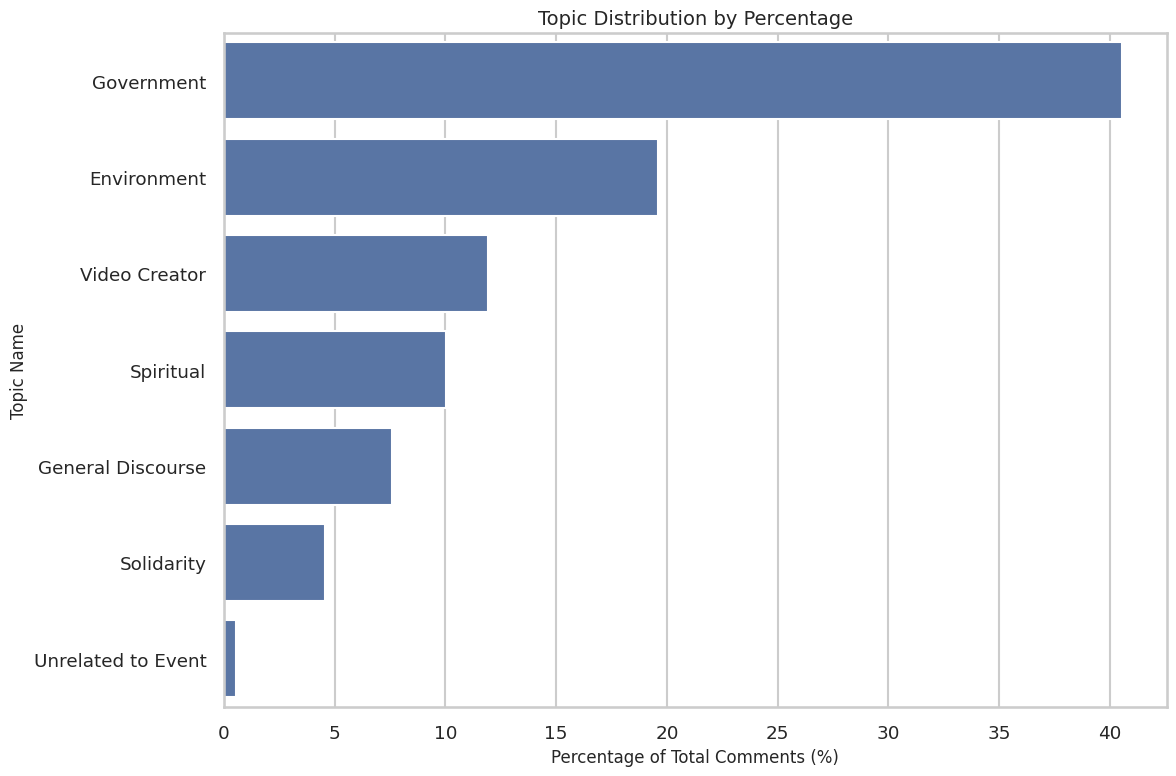

,topic_1_category,count,percentage
2,Government,12656,40.535520
0,Environment,6123,19.611172
6,Video Creator,3717,11.905067
4,Spiritual,3128,10.018577
1,General Discourse,2367,7.581193
3,Solidarity,1431,4.583307
5,Unrelated to Event,174,0.557299


In [43]:
plot_topic_distribution(merged_model_output_df, "topic_1_category")

## Government-Related Topic Distribution

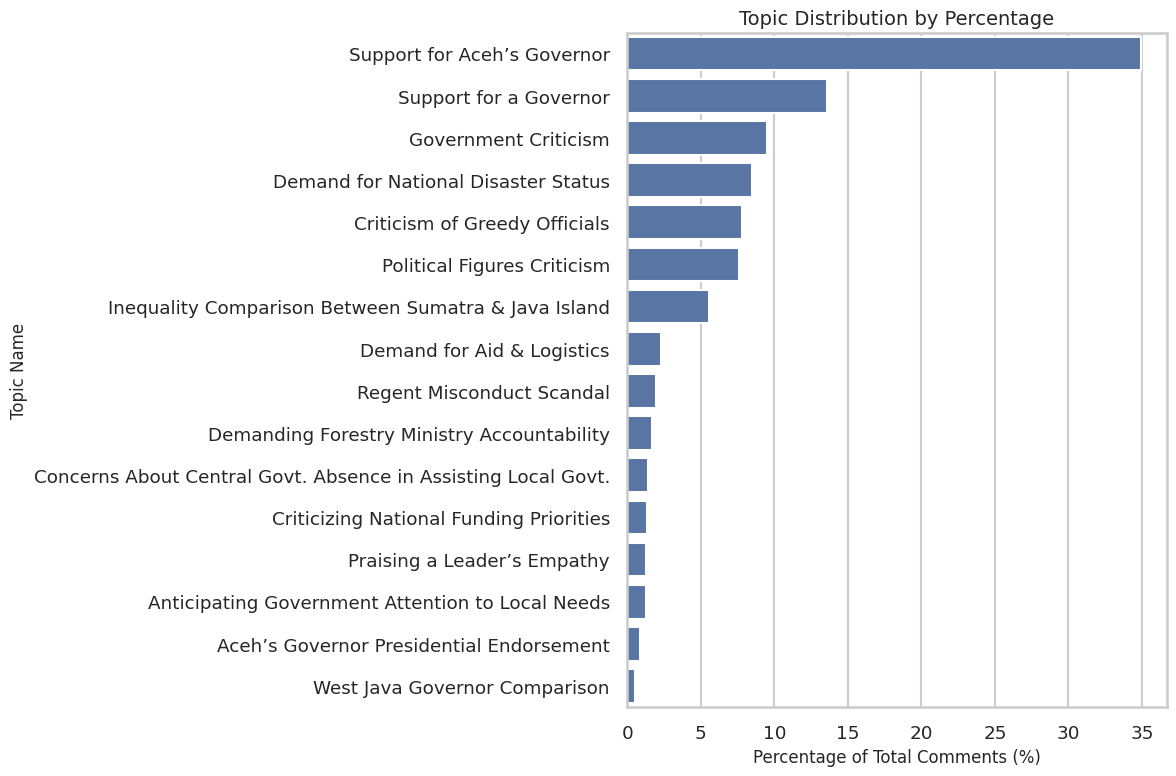

,topic_1_readable,count,percentage
13,Support for Aceh’s Governor,4422,34.939949
14,Support for a Governor,1722,13.606195
8,Government Criticism,1199,9.473767
6,Demand for National Disaster Status,1076,8.501896
3,Criticism of Greedy Officials,985,7.782870
10,Political Figures Criticism,963,7.609039
9,Inequality Comparison Between Sumatra & Java I...,700,5.530973
5,Demand for Aid & Logistics,287,2.267699
12,Regent Misconduct Scandal,248,1.959545
7,Demanding Forestry Ministry Accountability,214,1.690898


In [44]:
plot_topic_distribution(merged_model_output_df[merged_model_output_df['topic_1_category']=='Government'], "topic_1_readable")

## Environment-Related Topic Distribution


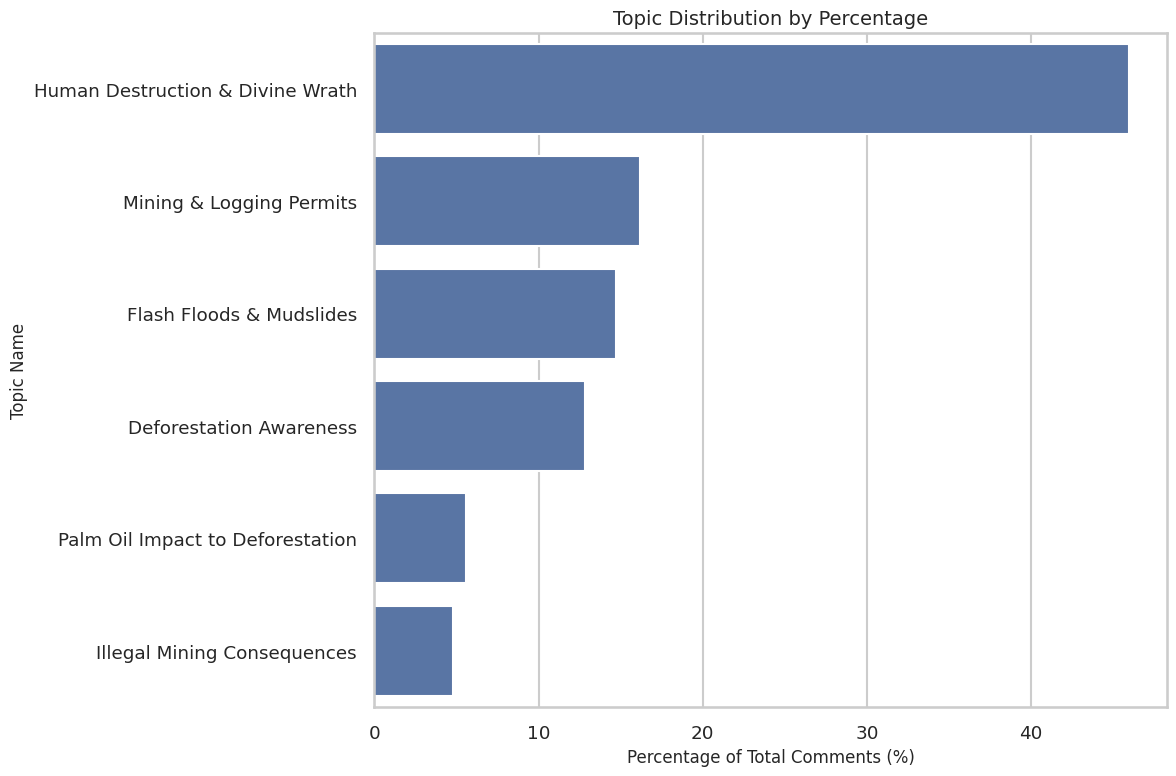

,topic_1_readable,count,percentage
2,Human Destruction & Divine Wrath,2814,45.957864
4,Mining & Logging Permits,990,16.168545
1,Flash Floods & Mudslides,899,14.682345
0,Deforestation Awareness,787,12.853177
5,Palm Oil Impact to Deforestation,340,5.552834
3,Illegal Mining Consequences,293,4.785236


In [45]:
plot_topic_distribution(merged_model_output_df[merged_model_output_df['topic_1_category']=='Environment'], "topic_1_readable")

## Topic x Emotion Interaction

In [46]:
merged_model_output_df = merged_model_output_df.merge(
    emosense_df[['comment_id', 'dominant_emotion']],
    on='comment_id',
    how='left'
)

In [47]:
merged_model_output_df.to_csv("merged_model_output_emotion.csv")

In [48]:
def plot_topic_emotion_heatmap(df, x_axis_col, y_axis_col, axis=0):
    """
    Plots a heatmap using standard Chi-Square Test and Pearson Residuals.
    - Color = Pearson Residuals (Red = Higher than expected, Blue = Lower than expected)
    - Text = Percentage distribution
    - Prints Top 5 Positive and Negative Residuals
    """

    crosstab = pd.crosstab(df[y_axis_col], df[x_axis_col])
    chi2_val, p, dof, expected = chi2_contingency(crosstab)
    residuals = (crosstab - expected) / np.sqrt(expected) # Pearson Residuals

    flat_residuals = residuals.stack().reset_index()
    flat_residuals.columns = ['Emotion', 'Topic', 'Residual']
  
    sorted_res = flat_residuals.sort_values(by='Residual', ascending=False)
    
    print("\n" + "="*80)
    print(f"📊 TOP 5 POSITIVE ASSOCIATIONS (Over-represented)")
    print("   (These emotions appear much MORE than expected for these topics)")
    print("-" * 80)
    print(f"{'Residual':<10} | {'Emotion':<15} | {'Topic'}")
    print("-" * 80)
    for _, row in sorted_res.head(5).iterrows():
        print(f"{row['Residual']:<10.2f} | {row['Emotion']:<15} | {row['Topic']}")
        
    print("\n" + "="*80)
    print(f"📉 TOP 5 NEGATIVE ASSOCIATIONS (Under-represented)")
    print("   (These emotions appear much LESS than expected for these topics)")
    print("-" * 80)
    print(f"{'Residual':<10} | {'Emotion':<15} | {'Topic'}")
    print("-" * 80)
    for _, row in sorted_res.tail(5).sort_values(by='Residual', ascending=True).iterrows():
        print(f"{row['Residual']:<10.2f} | {row['Emotion']:<15} | {row['Topic']}")
    print("="*80 + "\n")

    print(f"--- Chi-Square Test Results ---")
    print(f"Chi2 Statistic: {chi2_val:.4f}")
    print(f"p-value:        {p:.4e}")

    if axis == 0:
        pct_matrix = crosstab.apply(lambda x: x / x.sum(), axis=0) # Col %
        suffix = "P(Emotion | Topic)"
    else:
        pct_matrix = crosstab.apply(lambda x: x / x.sum(), axis=1) # Row %
        suffix = "P(Topic | Emotion)"
   
    text_labels = pct_matrix.map(lambda x: f"{x:.1%}")

    fig = px.imshow(
        residuals,
        labels=dict(x="Topic", y="Emotion", color="Pearson Residuals"),
        x=residuals.columns,
        y=residuals.index,
        color_continuous_scale="RdBu_r",
        color_continuous_midpoint=0,
        aspect="auto",
        title=f"Emotion Deviation by Topic (Chi-Square p={p:.1e})<br><sub>Color: Pearson Residuals (Red=High, Blue=Low) | Text: {suffix}</sub>"
    )
    
    fig.update_traces(text=text_labels.values, texttemplate="%{text}")
    fig.update_layout(width=1200, height=700, xaxis_tickangle=-45)
    fig.show()

In [50]:
topics_to_exclude = [42]
df_filtered = merged_model_output_df[~merged_model_output_df['topic_1'].isin(topics_to_exclude)].copy()
df_filtered.loc[df_filtered['topic_1'] == 39, 'topic_1'] = 0
df_filtered.loc[df_filtered['topic_1'] == 0, 'topic_1_readable'] = "Support for Aceh's Governor"
plot_topic_emotion_heatmap(
    df_filtered[df_filtered['topic_1_category']=='Government'], 
    x_axis_col='topic_1_readable', 
    y_axis_col='dominant_emotion', 
    axis=0
)


📊 TOP 5 POSITIVE ASSOCIATIONS (Over-represented)
   (These emotions appear much MORE than expected for these topics)
--------------------------------------------------------------------------------
Residual   | Emotion         | Topic
--------------------------------------------------------------------------------
22.65      | Anger           | Criticism of Greedy Officials
20.82      | Joy             | Support for Aceh's Governor
19.92      | Fear            | Demand for National Disaster Status
18.68      | Disgust         | Criticism of Greedy Officials
17.56      | Joy             | Support for a Governor

📉 TOP 5 NEGATIVE ASSOCIATIONS (Under-represented)
   (These emotions appear much LESS than expected for these topics)
--------------------------------------------------------------------------------
Residual   | Emotion         | Topic
--------------------------------------------------------------------------------
-20.27     | Anger           | Support for Aceh's Governor
-13.

In [51]:
plot_topic_emotion_heatmap(
    merged_model_output_df[merged_model_output_df['topic_1_category']=='Environment'], 
    x_axis_col='topic_1_readable', 
    y_axis_col='dominant_emotion', axis=0
)


📊 TOP 5 POSITIVE ASSOCIATIONS (Over-represented)
   (These emotions appear much MORE than expected for these topics)
--------------------------------------------------------------------------------
Residual   | Emotion         | Topic
--------------------------------------------------------------------------------
13.24      | Anger           | Mining & Logging Permits
8.95       | Fear            | Flash Floods & Mudslides
8.73       | Surprise        | Flash Floods & Mudslides
6.65       | Trust           | Human Destruction & Divine Wrath
5.63       | Anticipation    | Deforestation Awareness

📉 TOP 5 NEGATIVE ASSOCIATIONS (Under-represented)
   (These emotions appear much LESS than expected for these topics)
--------------------------------------------------------------------------------
Residual   | Emotion         | Topic
--------------------------------------------------------------------------------
-10.44     | Anger           | Flash Floods & Mudslides
-9.51      | Sadness  

## Government & Environment-Related Topics Correlation

A document can have multiple topics with distribution probabilities. This is the correlation of government-related and environment-related topics within a document. Larger number means that pair of topics often occur together.

Total environment-government pairs: 96
Pairs with strong correlation (r >= 0.5): 7
Percentage of pairs with r > 0.5: 7.29%



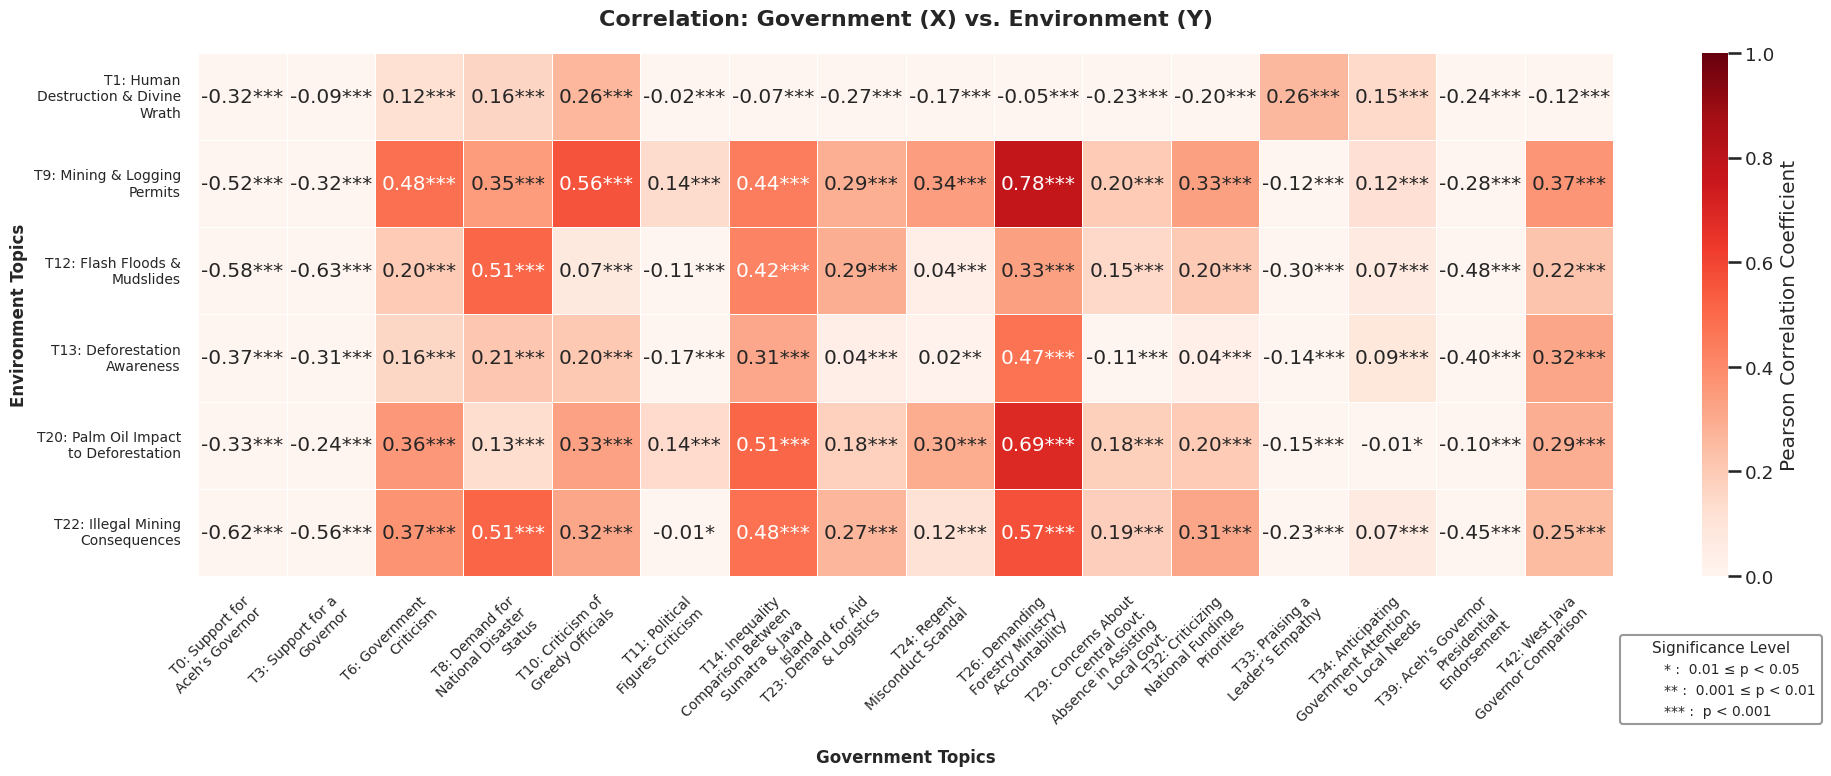

In [52]:
gov_topic_ids =  [0, 3, 6, 8, 10, 11, 14, 23, 24, 26, 29, 32, 33, 34, 39, 42]
env_topic_ids =  [1, 9, 12, 13, 20, 22]

def get_topic_info(df, topic_id_list, labels_dict):
    """
    Scans df.columns to find the full column name for each ID.
    Uses labels_dict to assign the readable name for plotting.
    """
    col_names = []
    nice_labels = []
    
    for tid in topic_id_list:
        prefix = f"prob_{tid}_"
        
        found = False
        for col in df.columns:
            if col.startswith(prefix):
                col_names.append(col)
                
                readable_name = labels_dict.get(tid, f"Unknown Topic {tid}")
                nice_labels.append(f"T{tid}: {readable_name}")
                
                found = True
                break
        
        if not found:
            print(f"Warning: Column for Topic {tid} not found!")
            
    return col_names, nice_labels


env_cols, env_labels = get_topic_info(merged_model_output_df, env_topic_ids, topic_labels)
gov_cols, gov_labels = get_topic_info(merged_model_output_df, gov_topic_ids, topic_labels)

def wrap_labels(labels, width=20):
    return ['\n'.join(textwrap.wrap(label, width)) for label in labels]

corr_matrix = merged_model_output_df[gov_cols + env_cols].corr()
target_corr = corr_matrix.loc[env_cols, gov_cols]

annot_labels = np.empty((len(env_cols), len(gov_cols)), dtype=object)

strong_corr_count = 0
total_pairs = len(env_cols) * len(gov_cols)

for i, env_col in enumerate(env_cols):
    for j, gov_col in enumerate(gov_cols):
        r, p = pearsonr(merged_model_output_df[env_col], merged_model_output_df[gov_col])

        if r >= 0.5:
            strong_corr_count += 1
            
        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        annot_labels[i, j] = f"{r:.2f}{stars}"

percentage = (strong_corr_count / total_pairs) * 100
print(f"Total environment-government pairs: {total_pairs}")
print(f"Pairs with strong correlation (r >= 0.5): {strong_corr_count}")
print(f"Percentage of pairs with r > 0.5: {percentage:.2f}%\n")


plt.figure(figsize=(20, 8)) 

wrapped_gov_labels = wrap_labels(gov_labels, width=20)
wrapped_env_labels = wrap_labels(env_labels, width=20)

ax = sns.heatmap(
    target_corr,
    xticklabels=wrapped_gov_labels,
    yticklabels=wrapped_env_labels,
    annot=annot_labels,
    fmt="",
    cmap="Reds",
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient"}
)

plt.title("Correlation: Government (X) vs. Environment (Y)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Environment Topics", fontsize=12, fontweight='bold')
plt.xlabel("Government Topics", fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right', rotation_mode='anchor', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_elements = [
    Line2D([0], [0], color='w', label='* :  0.01 \u2264 p < 0.05'),
    Line2D([0], [0], color='w', label='** :  0.001 \u2264 p < 0.01'),
    Line2D([0], [0], color='w', label='*** :  p < 0.001')
]

ax.legend(
    handles=legend_elements, 
    title="Significance Level",
    loc='upper left', 
    bbox_to_anchor=(1, -0.1),
    frameon=True,
    edgecolor='gray',
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout() 

plt.savefig("gov_env_corr_significant.png", dpi=300)
plt.show()